In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re

pd.set_option('display.max_colwidth', 100)
sns.set_style('whitegrid')

In [3]:
RAW_PATH = "../data/raw/complaints.csv"

cols_needed = [
    'Complaint ID', 'Product', 'Issue', 'Sub-issue',
    'Company', 'State', 'Date received', 'Consumer complaint narrative'
]

target_products = ['Credit card', 'Payday loan, title loan, or personal loan',
                    'Checking or savings account', 'Money transfer, virtual currency, or money service']

CHUNK_SIZE = 100_000
filtered_chunks = []

reader = pd.read_csv(
    RAW_PATH,
    usecols=cols_needed,
    dtype=str,          # avoid type-inference overhead, everything as string for now
    engine="c",         # force the C engine explicitly, bypass any pyarrow backend
    chunksize=CHUNK_SIZE
)

for i, chunk in enumerate(reader):
    chunk = chunk.dropna(subset=['Consumer complaint narrative'])
    chunk = chunk[chunk['Product'].isin(target_products)]
    filtered_chunks.append(chunk)
    print(f"Processed chunk {i+1}, kept {len(chunk)} rows so far this chunk "
          f"(running total: {sum(len(c) for c in filtered_chunks)})")

df = pd.concat(filtered_chunks, ignore_index=True)
print("Final filtered shape:", df.shape)

Processed chunk 1, kept 396 rows so far this chunk (running total: 396)
Processed chunk 2, kept 471 rows so far this chunk (running total: 867)
Processed chunk 3, kept 505 rows so far this chunk (running total: 1372)
Processed chunk 4, kept 640 rows so far this chunk (running total: 2012)
Processed chunk 5, kept 998 rows so far this chunk (running total: 3010)
Processed chunk 6, kept 1505 rows so far this chunk (running total: 4515)
Processed chunk 7, kept 1799 rows so far this chunk (running total: 6314)
Processed chunk 8, kept 3324 rows so far this chunk (running total: 9638)
Processed chunk 9, kept 5874 rows so far this chunk (running total: 15512)
Processed chunk 10, kept 3712 rows so far this chunk (running total: 19224)
Processed chunk 11, kept 2461 rows so far this chunk (running total: 21685)
Processed chunk 12, kept 2984 rows so far this chunk (running total: 24669)
Processed chunk 13, kept 2704 rows so far this chunk (running total: 27373)
Processed chunk 14, kept 1775 rows s

In [4]:
df.info()
df.columns.tolist()

<class 'pandas.DataFrame'>
RangeIndex: 335412 entries, 0 to 335411
Data columns (total 8 columns):
 #   Column                        Non-Null Count   Dtype
---  ------                        --------------   -----
 0   Date received                 335412 non-null  str  
 1   Product                       335412 non-null  str  
 2   Issue                         335412 non-null  str  
 3   Sub-issue                     203326 non-null  str  
 4   Consumer complaint narrative  335412 non-null  str  
 5   Company                       335412 non-null  str  
 6   State                         330414 non-null  str  
 7   Complaint ID                  335412 non-null  str  
dtypes: str(8)
memory usage: 416.0 MB


['Date received',
 'Product',
 'Issue',
 'Sub-issue',
 'Consumer complaint narrative',
 'Company',
 'State',
 'Complaint ID']

Product
Checking or savings account                           140319
Money transfer, virtual currency, or money service     97188
Credit card                                            80667
Payday loan, title loan, or personal loan              17238
Name: count, dtype: int64


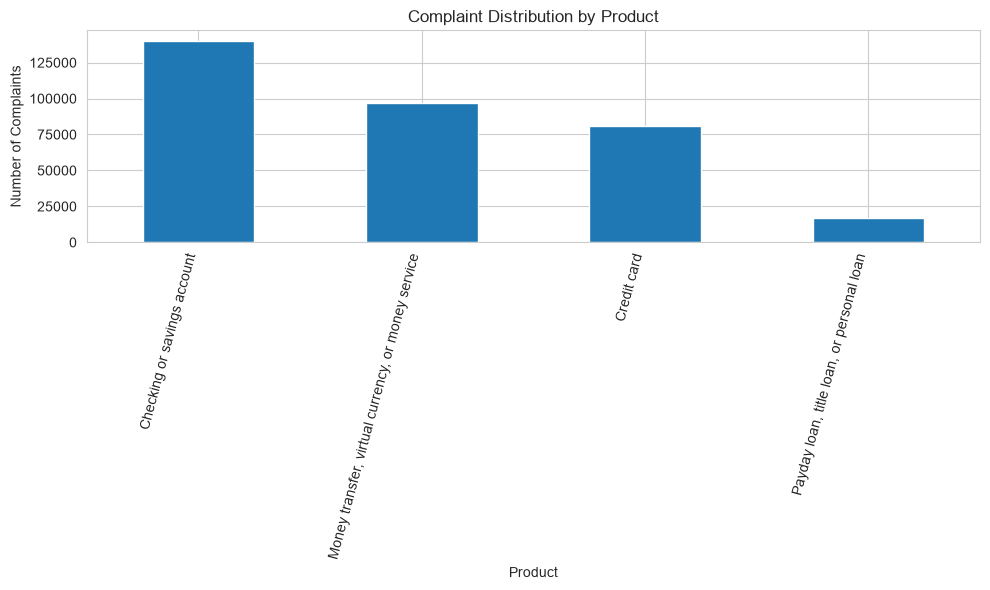

In [5]:
product_counts = df['Product'].value_counts()
print(product_counts)

plt.figure(figsize=(10, 6))
product_counts.plot(kind='bar')
plt.title('Complaint Distribution by Product')
plt.xlabel('Product')
plt.ylabel('Number of Complaints')
plt.xticks(rotation=75, ha='right')
plt.tight_layout()
plt.show()

In [6]:
has_narrative = df['Consumer complaint narrative'].notna().sum()
no_narrative = df['Consumer complaint narrative'].isna().sum()

print(f"With narrative: {has_narrative}")
print(f"Without narrative: {no_narrative}")
print(f"Percentage with narrative: {has_narrative / len(df) * 100:.2f}%")

With narrative: 335412
Without narrative: 0
Percentage with narrative: 100.00%


count    335412.000000
mean        199.450366
std         226.526703
min           1.000000
25%          81.000000
50%         127.000000
75%         245.000000
max        6469.000000
Name: word_count, dtype: float64


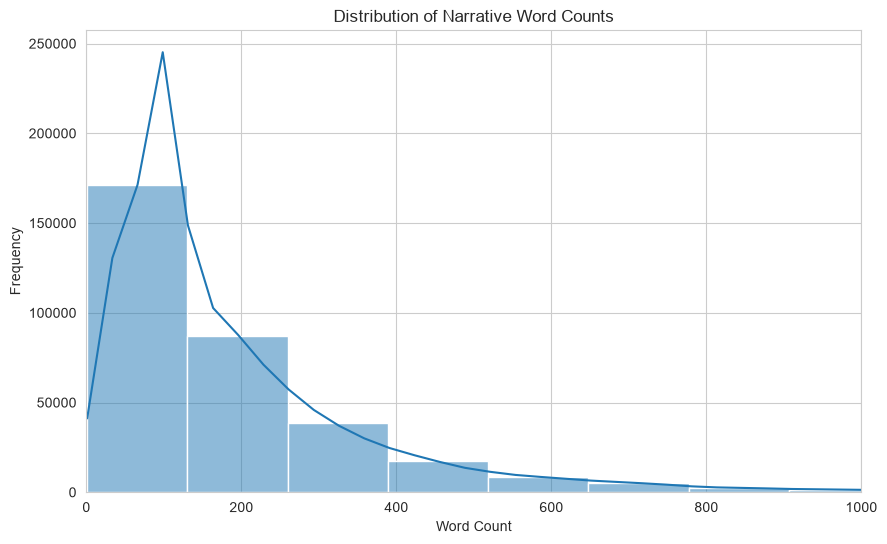

Very short (<5 words): 195
Very long (>1000 words): 3837


In [7]:
narrative_df = df[df['Consumer complaint narrative'].notna()].copy()
narrative_df['word_count'] = narrative_df['Consumer complaint narrative'].str.count(r'\S+')

print(narrative_df['word_count'].describe())

plt.figure(figsize=(10, 6))
sns.histplot(narrative_df['word_count'], bins=50, kde=True)
plt.title('Distribution of Narrative Word Counts')
plt.xlabel('Word Count')
plt.ylabel('Frequency')
plt.xlim(0, 1000)
plt.show()

# Flag very short / very long narratives
very_short = (narrative_df['word_count'] < 5).sum()
very_long = (narrative_df['word_count'] > 1000).sum()
print(f"Very short (<5 words): {very_short}")
print(f"Very long (>1000 words): {very_long}")

In [8]:
TARGET_PRODUCTS = ['Credit card', 'Personal loan', 'Savings account', 'Money transfer']

# CFPB product names are messy — inspect close matches first
print(df['Product'].unique())

<ArrowStringArray>
[                                       'Credit card',
                        'Checking or savings account',
 'Money transfer, virtual currency, or money service',
          'Payday loan, title loan, or personal loan']
Length: 4, dtype: str


In [9]:
# Adjust this mapping after inspecting unique values in Cell 7
product_map = {
    'Credit card': 'Credit Card',
    'Credit card or prepaid card': 'Credit Card',
    'Payday loan, title loan, or personal loan': 'Personal Loan',
    'Consumer Loan': 'Personal Loan',
    'Checking or savings account': 'Savings Account',
    'Money transfer, virtual currency, or money service': 'Money Transfer',
    'Money transfers': 'Money Transfer',
}

df['product_category'] = df['Product'].map(product_map)
filtered_df = df[df['product_category'].notna()].copy()
filtered_df = filtered_df[filtered_df['Consumer complaint narrative'].notna()].copy()

print(filtered_df['product_category'].value_counts())
print(f"Filtered shape: {filtered_df.shape}")

product_category
Savings Account    140319
Money Transfer      97188
Credit Card         80667
Personal Loan       17238
Name: count, dtype: int64
Filtered shape: (335412, 9)


In [10]:
def clean_narrative(text):
    text = text.lower()
    # remove common boilerplate openers
    boilerplate_patterns = [
        r"i am writing to file a complaint.*?\.",
        r"this is a complaint regarding.*?\.",
        r"to whom it may concern,?",
    ]
    for pattern in boilerplate_patterns:
        text = re.sub(pattern, '', text, flags=re.IGNORECASE)
    # remove redaction placeholders like XX/XX/XXXX or XXXX
    text = re.sub(r'x{2,}', '', text)
    # remove special characters, keep basic punctuation
    text = re.sub(r'[^a-z0-9\s\.\,\?\!\']', ' ', text)
    # collapse whitespace
    text = re.sub(r'\s+', ' ', text).strip()
    return text

filtered_df['cleaned_narrative'] = filtered_df['Consumer complaint narrative'].apply(clean_narrative)
filtered_df[['Consumer complaint narrative', 'cleaned_narrative']].head()

,Consumer complaint narrative,cleaned_narrative
0,A XXXX XXXX card was opened under my name by a fraudster. I received a notice from XXXX that an...,a card was opened under my name by a fraudster. i received a notice from that an account was jus...
1,I made the mistake of using my wellsfargo debit card to depsit funds Into XXXXXXXX ATM machine o...,i made the mistake of using my wellsfargo debit card to depsit funds into atm machine outside th...
2,"Dear CFPB, I have a secured credit card with citibank which is changed to unsecured card and I h...","dear cfpb, i have a secured credit card with citibank which is changed to unsecured card and i h..."
3,"I have a Citi rewards cards. The credit balance issued to me was {$8400.00}. I recently moved, w...","i have a citi rewards cards. the credit balance issued to me was 8400.00 . i recently moved, whi..."
4,b'I am writing to dispute the following charges on my CITI Credit Card Accounts where I have bec...,b'i am writing to dispute the following charges on my citi credit card accounts where i have bec...


In [11]:
output_cols = ['Complaint ID', 'product_category', 'Product', 'Issue', 'Sub-issue',
               'Company', 'State', 'Date received', 'cleaned_narrative']

final_df = filtered_df[[c for c in output_cols if c in filtered_df.columns]].copy()
final_df.to_csv('../data/processed/filtered_complaints.csv', index=False)
print(f"Saved {len(final_df)} rows to data/processed/filtered_complaints.csv")

Saved 335412 rows to data/processed/filtered_complaints.csv
